In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("sales_data.csv")
print(df.head())

         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001  Electronics  North              195   
1  2022-01-01     S001      P0002     Clothing  North              117   
2  2022-01-01     S001      P0003     Clothing  North              247   
3  2022-01-01     S001      P0004  Electronics  North              139   
4  2022-01-01     S001      P0005    Groceries  North              152   

   Units Sold  Units Ordered  Price  Discount Weather Condition  Promotion  \
0         102            252  72.72         5             Snowy          0   
1         117            249  80.16        15             Snowy          1   
2         114            612  62.94        10             Snowy          1   
3          45            102  87.63        10             Snowy          0   
4          65            271  54.41         0             Snowy          0   

   Competitor Pricing Seasonality  Epidemic  Demand  
0               85.73      Winte

In [3]:
print(df.isnull().sum())

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64


In [4]:
cat_columns = ["Store ID","Product ID","Category"]

In [5]:
for col in cat_columns:
    df[col] = df[col].astype(str).str.strip()

In [6]:
df = pd.get_dummies(df, columns=cat_columns)

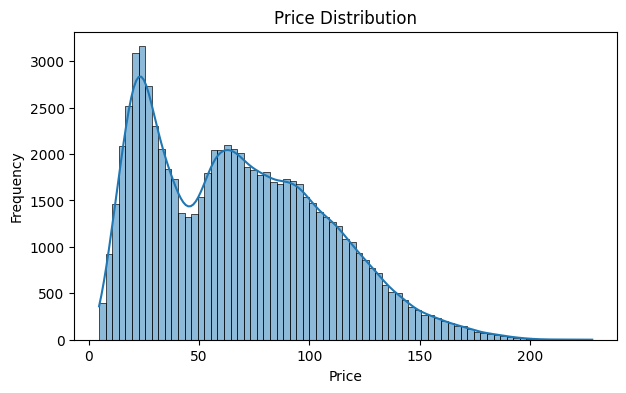

In [7]:
plt.figure(figsize=(7,4))
sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

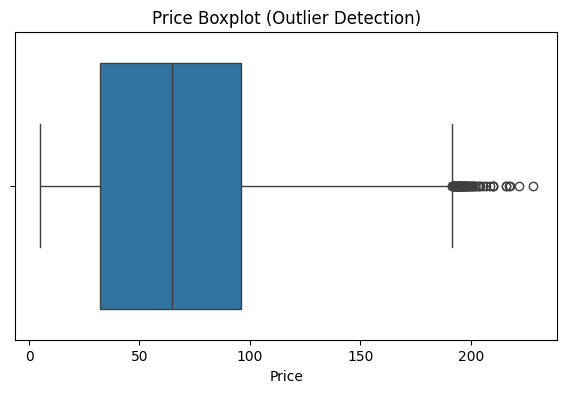

In [8]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df['Price'])
plt.title("Price Boxplot (Outlier Detection)")
plt.show()

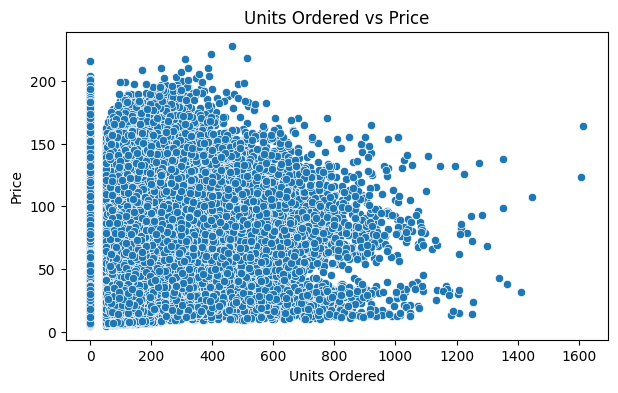

In [9]:
plt.figure(figsize=(7,4))
sns.scatterplot(x=df['Units Ordered'], y=df['Price'])
plt.title("Units Ordered vs Price")
plt.show()

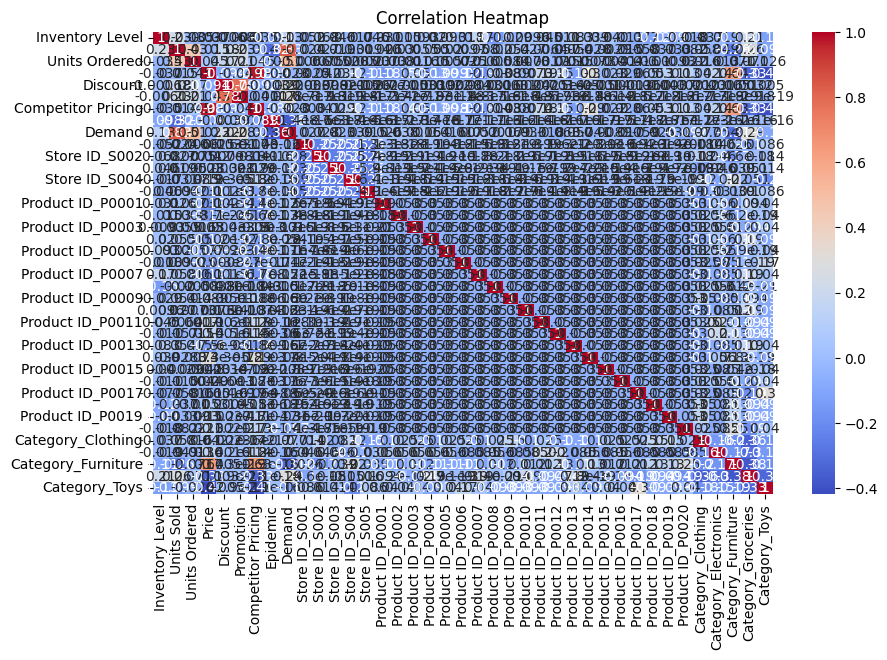

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [27]:
x = df.drop('Price', axis=1)
y = df['Price']

In [28]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]

In [29]:

x = df.drop('Price', axis=1)
y = df['Price']

In [30]:
feature_train, feature_test, target_train, target_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [31]:
model = DecisionTreeRegressor(random_state=42)


In [32]:
model.fit(feature_train, target_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [33]:
print("Model trained successfully")

Model trained successfully


In [34]:
y_pred = model.predict(feature_test)

In [35]:
print("MSE:", mean_squared_error(target_test, y_pred))
print("R2 Score:", r2_score(target_test, y_pred))

MSE: 30.905466980263157
R2 Score: 0.9801042180231547
